# Inverse Problem Example: Sinusoid

This notebook demonstrates how to solve a simple inverse problem using [EnsembleKalmanProcesses.jl](https://clima.github.io/EnsembleKalmanProcesses.jl/stable/), a Julia package for gradient-free parameter estimation using ensemble-based methods.

## Problem Setup

An *inverse problem* starts from a set of observed data `y`, an assumed forward model `G(θ)`, and some model or measurement noise `Γ`. The goal is to infer the unknown parameters `θ` that most likely produced the observations.

We assume the following observational model:

$$
y = G(\theta) + \Gamma
$$

Our objective is to estimate the optimal parameters $\theta^*$ such that:

$$
G(\theta^*) \approx y
$$

In this example, our forward model is a sinusoidal function with an unknown amplitude and vertical shift:

$$
G(A, v) = A \sin(\phi + t) + v, \quad \forall t \in [0, 2\pi]
$$

Here:
- $A$ is the amplitude
- $v$ is the vertical shift
- $\phi$ is a fixed (but unknown) phase shift, treated as part of the noise
- $t$ is a vector of input values over $[0, 2\pi]$

Our observations `y` consist of summary statistics of the true signal: the **maximum - minimum** and the **mean**. From these noisy statistics, we aim to infer the underlying values of $A$ and $v$.

We assume that the true parameters were drawn from:
- $A^* \sim \mathcal{N}(2, 1)$
- $v^* \sim \mathcal{N}(0, 25)$

## Parameter Estimation with Ensemble Kalman Process (EKP)

The Ensemble Kalman Process (EKP) is an iterative, derivative-free algorithm designed for solving inverse problems. It generalizes the Ensemble Kalman Filter (EnKF) to parameter estimation, treating unknown parameters as latent states to be inferred.


### Key Advantages

- **Derivative-free**: No need to compute gradients of complex Earth system models
- **Handles nonlinearity**: Works with highly nonlinear forward models
- **Quantifies uncertainty**: Provides ensemble-based uncertainty estimates
- **Scalable**: Efficient for high-dimensional parameter and data spaces

Algorithm Overview

1. Initialize an ensemble of parameter vectors from prior distributions
2. Evaluate the forward model for each ensemble member
3. Compute empirical statistics (mean, covariance) of model outputs
4. Update parameters using Kalman-inspired rules based on observation mismatch
5. Iterate steps 2-4 until convergence

This method provides a practical approach to solving inverse problems in scientific applications where the forward model is nonlinear or complex (e.g. land modeling).

### Setup and Dependencies

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"]=0
using Pkg
required_pkgs = ["EnsembleKalmanProcesses", "CairoMakie", "LinearAlgebra", "Random", "Distributions"]
Pkg.add(required_pkgs)
Pkg.instantiate()
Pkg.precompile()

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed OpenBLAS32_jll ─────────── v0.3.29+0
   Installed FastGaussQuadrature ────── v1.0.2
   Installed SCS ────────────────────── v1.1.2
   Installed MutableArithmetics ─────── v1.6.4
   Installed AMD ────────────────────── v0.5.3
   Installed Convex ─────────────────── v0.15.4
   Installed EnsembleKalmanProcesses ── v1.1.5
   Installed MathOptInterface ───────── v1.42.1
   Installed FiniteDiff ─────────────── v2.28.1
   Installed NLSolversBase ──────────── v7.10.0
   Installed StructTypes ────────────── v1.11.0
   Installed JSON3 ──────────────────── v1.14.3
   Installed PositiveFactorizations ─── v0.2.4
   Installed BenchmarkTools ─────────── v1.6.0
   Installed CodecBzip2 ─────────────── v0.8.5
   Installed LineSearches ───────────── v7.4.0
   Installed SCS_GPU_jll ────────────── v3.2.0+0
   Installed Graphics ───────────────── v1.1.3
   Installed UnPack ─────────────────── v1.0.2
   

In [ ]:
using LinearAlgebra, Random
using Distributions, Plots
using CairoMakie
CairoMakie.activate!()
using EnsembleKalmanProcesses.ParameterDistributions
import EnsembleKalmanProcesses as EKP

rng_seed = 1234
rng = Random.MersenneTwister(rng_seed)

[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] 
[ Info: Precompiling EnsembleKalmanProcesses [aa8a2aa5-91d8-4396-bcef-d4f2ec43552d] 
[ Info: Precompiling DifferentiationInterfaceChainRulesCoreExt [9dc9f1db-29b2-5863-acb4-b3b6c4880d6a] 


MersenneTwister(1234)

## Forward Model Definition

We define our sinusoidal model with a random phase shift to simulate model uncertainty:

In [ ]:
dt = 0.01
time_range = 0:dt:(2 * pi + dt)
function model(amplitude, vert_shift)
    phi = 2 * pi * rand(rng)
    return amplitude * sin.(time_range .+ phi) .+ vert_shift
end

model (generic function with 1 method)

## Observation Map

The full forward map G maps from raw model output to observations consisting of summary statistics:

In [ ]:
function G(theta)
    theta, vert_shift = theta
    sincurve = model(theta, vert_shift)
    return [maximum(sincurve) - minimum(sincurve), mean(sincurve)]
end

G (generic function with 1 method)

Now we generate our synthetic observations using our "true" parameters.

In [ ]:
true_amplitude = 1.0
true_vertical_shift = 7.0
theta_true = (true_amplitude, true_vertical_shift)

Γ = 0.1 * I
noise_dist = MvNormal(zeros(2), Γ)
y = G(theta_true) .+ rand(noise_dist)

2-element Vector{Float64}:
 1.7698528378718463
 7.257942722944606

Now we define our multivariate normal prior distribution using the `constrained_gaussian` function.`constrained_gaussian` takes in a name, mean, standard deviation, and bounds. The constraints refer to the bounds placed on the prior distribution.

 For the amplitude, we define a prior with mean 2 and standard deviation 1. It is additionally constrained to be nonnegative. For the vertical shift we define a Gaussian prior with mean 0 and standard deviation 5.



In [ ]:
prior_u1 = constrained_gaussian("amplitude", 2, 1, 0, Inf)
prior_u2 = constrained_gaussian("vert_shift", 0, 5, -Inf, Inf)
prior = combine_distributions([prior_u1, prior_u2])

ParameterDistribution with 2 entries: 
'amplitude' with Constraint[Bounds: (0, ∞)] over distribution Parameterized(Normal{Float64}(μ=0.5815754049028404, σ=0.47238072707743883)) 
'vert_shift' with Constraint[Bounds: (-∞, ∞)] over distribution Parameterized(Normal{Float64}(μ=0.0, σ=5.0)) 


We now generate the initial ensemble and set up the ensemble Kalman inversion. We set a random seed to ensure reproducibility of our results.

In [ ]:
N_ensemble = 10
N_iterations = 7

initial_ensemble = EKP.construct_initial_ensemble(rng, prior, N_ensemble)
ensemble_kalman_process = EKP.EnsembleKalmanProcess(initial_ensemble, y, Γ, EKP.Inversion(); rng);

## Run the Inversion

We are now ready to carry out the inversion. At each iteration, we get the ensemble from the last iteration, apply $G(\theta)$ to each ensemble member, and apply the Kalman update to the ensemble.

In [ ]:
for i in 1:N_iterations
    params_i = EKP.get_ϕ_final(prior, ensemble_kalman_process)

    G_ens = hcat([G(params_i[:, i]) for i in 1:N_ensemble]...)

    EKP.update_ensemble!(ensemble_kalman_process, G_ens)
end

## Results & Analysis


Now we can get the final ensemble, structured as a matrix where each row is a different parameter and each column is a different ensemble member

In [ ]:
final_ensemble = EKP.get_ϕ_final(prior, ensemble_kalman_process)

2×10 Matrix{Float64}:
 0.86354  0.802635  0.829639  0.899949  …  0.861398  0.822371  0.913173
 7.39293  7.13608   7.3888    7.3492       7.34515   7.10586   7.22077

We can also obtain just the mean parameter values:

In [ ]:
final_mean = EKP.get_ϕ_mean_final(prior, ensemble_kalman_process)

2-element Vector{Float64}:
 0.8770170774817105
 7.267473829379763

The final values are close to the true amplittude and vertical shift, and the small spread in the full final ensemble indicates confidence in the final result.

## Visualization

In [ ]:

# Create the figure and axis
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "Model output")

# Plot the true model
lines!(ax, time_range, model(theta_true...), color = :black, linewidth = 2, label = "Truth")

# Plot the initial ensemble
for i in 1:N_ensemble
    lines!(
        ax,
        time_range,
        model(EKP.get_ϕ(prior, ensemble_kalman_process, 1)[:, i]...),
        color = :red,
        label = i == 1 ? "Initial ensemble" : ""
    )
end

# Plot the final ensemble
for i in 1:N_ensemble
    lines!(
        ax,
        time_range,
        model(final_ensemble[:, i]...),
        color = :blue,
        label = i == 1 ? "Final ensemble" : ""
    )
end

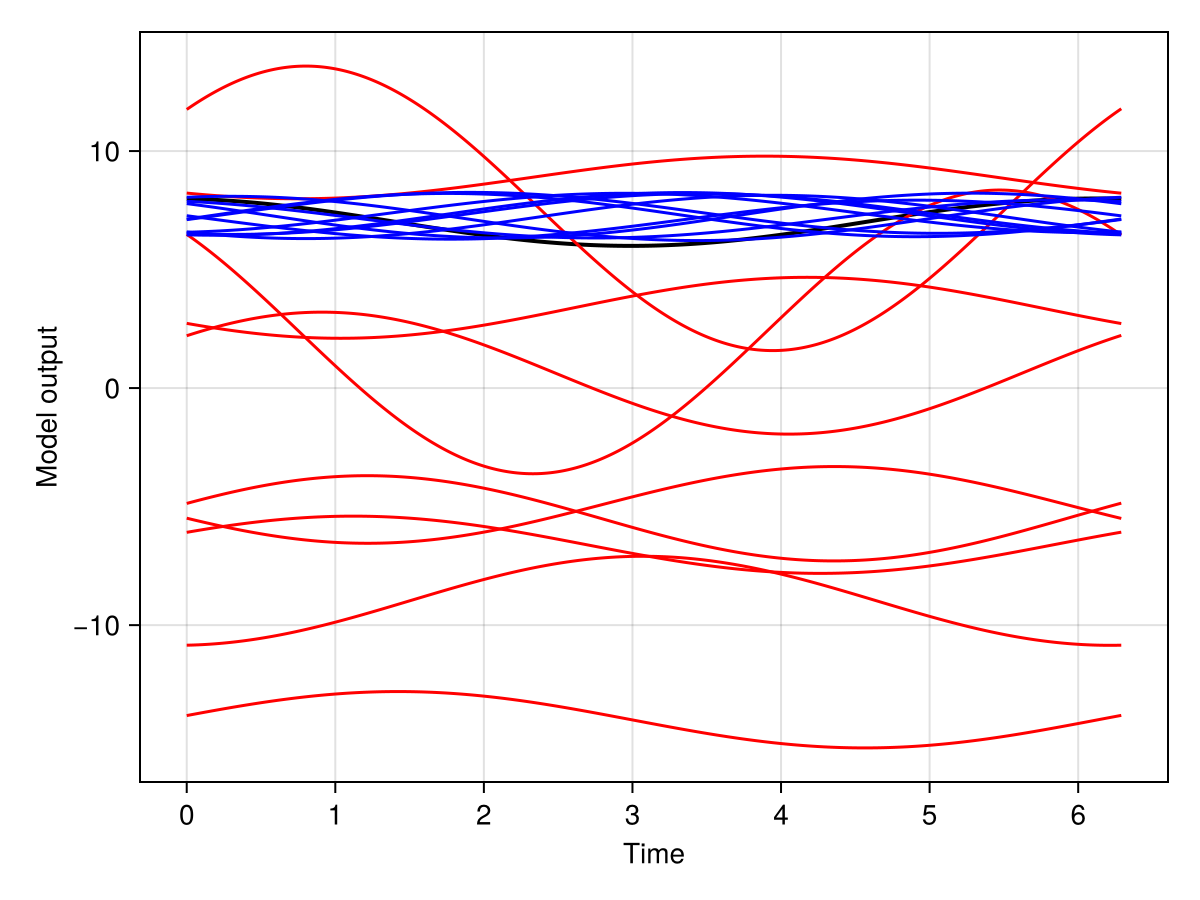

In [ ]:
fig

In [ ]:
save("fig.png", fig)